<a href="https://colab.research.google.com/github/sergiomora03/AdvancedTopicsAnalytics/blob/main/exercises/E2-HomeworksAnalysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**INTEGRANTES:**
- Luis Alejandro Garzón Ramirez
- Zorayda Acevedo Jimenez
- Yulieth Danitza Aguillón Ortega

# Exercise 2

## Analyze class homeworks


In [ ]:
import pandas as pd
import numpy as np

%matplotlib inline
import matplotlib.pyplot as plt

data = pd.read_excel('https://github.com/sergiomora03/AdvancedTopicsAnalytics/raw/main/datasets/Consolidado_respuestas_escribir_v2.xlsx')
data.head()

,Genero,E1 - Examples of Time Series Analysis,E4 - Panel Data,E6 - Decison Trees,E8 - Ensemble Trees Overview,E10 - REST-API,E11 - Natural Language Processing Overview
0,M,One of the most valuable application of time s...,The main difference between panel data and tim...,Decision tree are a model used by the analytic...,They are used to make a better prediction than...,Es una forma de arquitectura de datos. Los mic...,NaN
1,F,ANÁLISIS DE SERIES DE TIEMPO – USOS \nEl análi...,Series de Tiempo vs Datos en Panel\nUna serie ...,TIPOS DE ÁRBOLES DE DECISIÓN Y APLICACIONES\nL...,ENSAMBLAJE EN MACHINE LEARNING\nLos métodos de...,Microservicios\nEl objetivo principal de la im...,NaN
2,M,Una serie de tiempo es una colección de datos ...,NaN,los arboles de decisión hacen parte de los alg...,Ensemble methods is a machine learning techniq...,El enfoque tradicional para el diseño de aplic...,"LexisNexis launched Lexis Analytics, a legal r..."
3,M,\nGiven that Time Series Analysis allows to un...,The difference between panel data and time ser...,Decision Trees Algorithms are machine function...,Ensemble methods in Tree Decision algorithms b...,Micro-services are defined as a type of softwa...,NaN
4,M,Time Series Analysis is concerned with the stu...,A time series is represented by a variable or ...,Decision trees are a popular supervised machin...,The ensemble method is a combination of severa...,A microservice is a type of information techno...,A commercial product which uses Natural Langua...


In [ ]:
import pandas as pd
import spacy
import nltk
import numpy as np
from collections import Counter
from sklearn.feature_extraction.text import TfidfVectorizer
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import torch
import numpy as np
from torch.utils.data import Dataset, DataLoader, random_split
from transformers import DistilBertTokenizer, DistilBertForSequenceClassification
from torch.optim import AdamW
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import pandas as pd
from nltk.corpus import stopwords
import re
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics.pairwise import cosine_distances
from sentence_transformers import SentenceTransformer
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import optuna
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier



In [ ]:
data.shape

(46, 7)

# Exercise 2.1

Analyze the writing patterns of each student

In [ ]:
!pip install spacy nltk
!python -m spacy download es_core_news_sm


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.9/12.9 MB 56.5 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('es_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


Hacemos un preprocesado de los datos

In [ ]:
df=data

nlp = spacy.load("es_core_news_sm")


nltk.download("stopwords")
stop_words = set(stopwords.words("spanish"))

def limpiar_texto(texto):
    if pd.isna(texto):
        return ""

    # Convertir a minúsculas
    texto = texto.lower()

    # Eliminar caracteres especiales y números
    texto = re.sub(r"[^a-záéíóúüñ ]", "", texto)

    # Tokenización y eliminación de stopwords usando spaCy
    doc = nlp(texto)
    tokens = [token.lemma_ for token in doc if token.text not in stop_words and not token.is_punct]

    return " ".join(tokens)

# Aplicar la limpieza a todas las respuestas del dataset
df.iloc[:, 1:] = df.iloc[:, 1:].applymap(limpiar_texto)

# Crear la nueva columna `texto_completo`
df["texto_completo"] = df.iloc[:, 1:].apply(lambda x: " ".join(x), axis=1)

df.head()


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
<ipython-input-87-d447e79c3bf2>:28: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df.iloc[:, 1:] = df.iloc[:, 1:].applymap(limpiar_texto)


,Genero,E1 - Examples of Time Series Analysis,E4 - Panel Data,E6 - Decison Trees,E8 - Ensemble Trees Overview,E10 - REST-API,E11 - Natural Language Processing Overview,texto_completo
0,M,onir of the most valuable application of time ...,the main difference betwear panel datar and ti...,decision tree are model used by the analytics ...,they are used to make better prediction thaber...,forma arquitectura dato microservicio hacer ap...,,onir of the most valuable application of time ...
1,F,análisis serie tiempo uso análisis serie tie...,serie tiempo vs dato paneluna serie tiempo per...,tipo árbol decisión aplicaciones él árbol deci...,ensamblaje machine learninglos método ensambla...,microserviciosel objetivo principal implementa...,,análisis serie tiempo uso análisis serie tie...
2,M,serie tiempo colección dato valor variable rec...,,arbol decisión hacer parte algoritmo aprendiza...,ensemble methods is machine learning technique...,enfoque tradicional diseño aplicación centrar ...,lexisnexi launched lexis analytics legal resea...,serie tiempo colección dato valor variable rec...
3,M,givir that time serie analysis allows to under...,the difference betwear panel datar and time se...,decision trees algorithms are machine function...,ensemble methods in tree decision algorithms b...,microserviz are defined as type of software ar...,,givir that time serie analysis allows to under...
4,M,time serie analysis is concerned with the stud...,time seri is represented by variable or set of...,decision trees are popular supervised machine ...,the ensemble method is combination of several ...,microservice is type of information technology...,commercial product which uses natural language...,time serie analysis is concerned with the stud...


Primeras descriptivas de los patrones de escritura por estudiante

In [ ]:

def analizar_texto(texto):
    doc = nlp(texto)

    # 1. Diversidad léxica
    palabras = [token.text for token in doc if token.is_alpha]
    palabras_unicas = set(palabras)
    diversidad_lexica = len(palabras_unicas) / len(palabras) if palabras else 0

    # 2. Longitud de oraciones
    oraciones = list(doc.sents)
    longitud_prom_oraciones = np.mean([len(oracion) for oracion in oraciones]) if oraciones else 0

    # 3. Complejidad de palabras
    longitud_prom_palabra = np.mean([len(palabra) for palabra in palabras]) if palabras else 0
    porcentaje_palabras_largas = sum(1 for w in palabras if len(w) > 6) / len(palabras) if palabras else 0

    # 4. Uso de stopwords
    num_stopwords = sum(1 for palabra in palabras if palabra in stop_words)
    porcentaje_stopwords = num_stopwords / len(palabras) if palabras else 0

    # 5. Distribución de Partes del Discurso
    conteo_pos = Counter([token.pos_ for token in doc])

    return {
        "diversidad_lexica": diversidad_lexica,
        "longitud_prom_oraciones": longitud_prom_oraciones,
        "longitud_prom_palabra": longitud_prom_palabra,
        "porcentaje_palabras_largas": porcentaje_palabras_largas,
        "porcentaje_stopwords": porcentaje_stopwords,
        "porcentaje_sustantivos": conteo_pos.get("NOUN", 0) / len(palabras) if palabras else 0,
        "porcentaje_verbos": conteo_pos.get("VERB", 0) / len(palabras) if palabras else 0,
        "porcentaje_adjetivos": conteo_pos.get("ADJ", 0) / len(palabras) if palabras else 0,
    }

# Aplicar análisis a cada estudiante
patrones_escritura = df["texto_completo"].apply(analizar_texto)
df_patrones = pd.DataFrame(list(patrones_escritura))

# Análisis de palabras clave con TF-IDF (palabras más importantes por estudiante)
vectorizador = TfidfVectorizer(stop_words=list(stop_words))
matriz_tfidf = vectorizador.fit_transform(df["texto_completo"])
nombres_palabras = np.array(vectorizador.get_feature_names_out())

# Obtener las 3 palabras más relevantes para cada estudiante
palabras_clave_por_estudiante = []
for fila in matriz_tfidf.toarray():
    palabras_top = nombres_palabras[np.argsort(fila)[-3:][::-1]]  # Top 3 palabras más significativas
    palabras_clave_por_estudiante.append(", ".join(palabras_top))

df_patrones["palabras_clave"] = palabras_clave_por_estudiante

# Similitud entre estudiantes usando embeddings
modelo = SentenceTransformer("distiluse-base-multilingual-cased-v1")
X_estudiantes = modelo.encode(df["texto_completo"].tolist(), convert_to_tensor=False)
matriz_similitud_estudiantes = cosine_similarity(X_estudiantes)

# Agregar el estudiante más similar para cada uno
df_patrones["estudiante_mas_similar"] = df.index[np.argmax(matriz_similitud_estudiantes, axis=1)]

# Mostrar resultados
print(df_patrones)

    diversidad_lexica  longitud_prom_oraciones  longitud_prom_palabra  \
0            0.447417                   1087.0               5.583948   
1            0.545872                    899.0               8.294725   
2            0.533333                    948.0               6.721505   
3            0.354669                    668.0               5.290663   
4            0.398257                   1979.0               5.412096   
5            0.588398                    728.0               6.305249   
6            0.476821                    379.5               7.157616   
7            0.519608                    377.5               7.400560   
8            0.705479                    297.0               7.736301   
9            0.693215                    347.0               7.687316   
10           0.580696                    640.0               7.354430   
11           0.575377                    809.0               7.804020   
12           0.522465                    788.0     

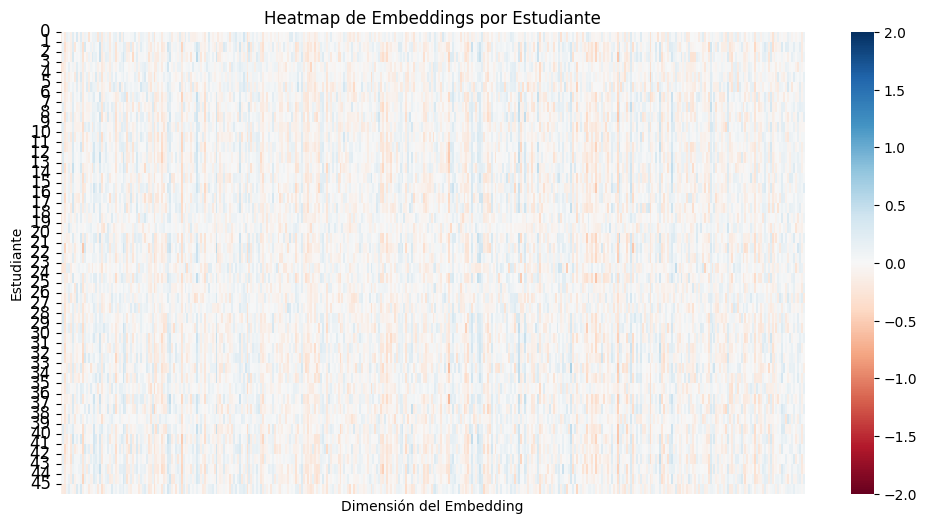

In [ ]:
# Cargar modelo de embeddings
modelo = SentenceTransformer("paraphrase-MiniLM-L3-v2")


# Obtener los embeddings del texto completo
embeddings = modelo.encode(df["texto_completo"].tolist())  # Matriz de embeddings

# Convertir embeddings en un DataFrame donde las filas son los estudiantes
df_embeddings = pd.DataFrame(embeddings, index=df.index)

# Función para graficar el heatmap
def plot_embeddings(vectors):
    fig, ax = plt.subplots(figsize=(12, 6))

    sns.heatmap(vectors, cmap="RdBu", vmax=2, vmin=-2, ax=ax)
    ax.set_yticks(np.arange(len(vectors.index)))
    ax.set_yticklabels(vectors.index, rotation=0, fontsize=12)
    ax.set_xticks([])

    plt.title("Heatmap de Embeddings por Estudiante")
    plt.xlabel("Dimensión del Embedding")
    plt.ylabel("Estudiante")

    plt.show()

# Graficar el heatmap de embeddings
plot_embeddings(df_embeddings)



La matriz es muy dispersa, hay muy pocas dimensiones con presencia de color parecido en todos los estudiasntes, probablemente las referidas a los topicos analizados, sin embargo con esta aproximación inicial es muy dificil determinar estudiantes con patrones de escritura parecidos.

# Exercise 2.2

Evaluate the similarities of the homeworks of the students.

At a homework level, then as a student level.


Matriz de similitud segun distancia del coseno

Homework level

                                       E1 - Examples of Time Series Analysis  \
E1 - Examples of Time Series Analysis                               1.000000   
E4 - Panel Data                                                     0.402149   
E6 - Decison Trees                                                  0.144619   
E8 - Ensemble Trees Overview                                        0.246828   
E10 - REST-API                                                      0.156357   

                                       E4 - Panel Data  E6 - Decison Trees  \
E1 - Examples of Time Series Analysis         0.402149            0.144619   
E4 - Panel Data                               1.000000            0.108333   
E6 - Decison Trees                            0.108333            1.000000   
E8 - Ensemble Trees Overview                  0.262796            0.564855   
E10 - REST-API                                0.413496            0.164602   

                                       E8 - Ensemb

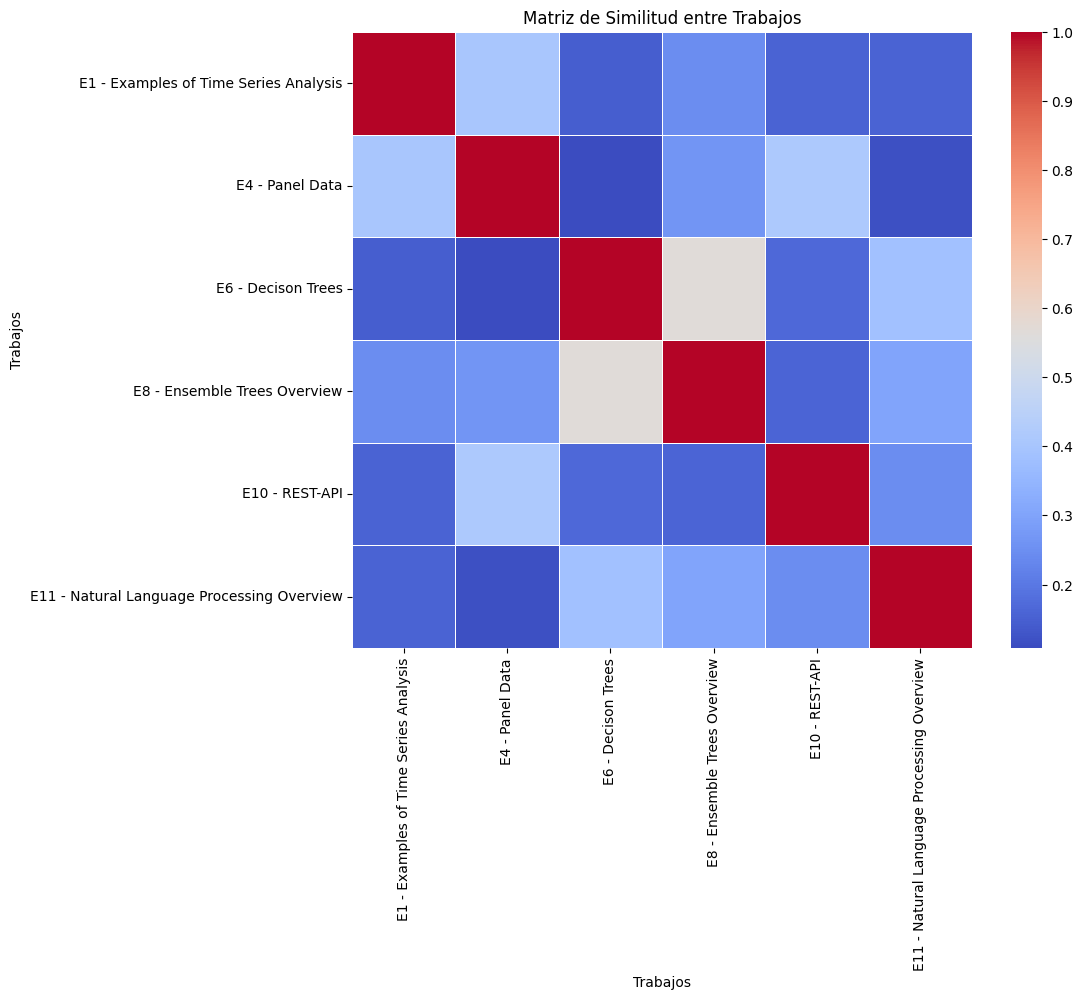

In [ ]:
# Transponer el DataFrame
df_t = df.iloc[:, 1:-1].T

df_t["texto_completo"] = df_t.fillna("").apply(lambda x: " ".join(x), axis=1)

# Cargar el modelo
model = SentenceTransformer("paraphrase-MiniLM-L3-v2")

# Convertir textos de trabajos en embeddings
X_jobs = model.encode(df_t["texto_completo"].tolist(), convert_to_tensor=False)

# Calcular la matriz de similitud del coseno entre trabajos
similarity_matrix_jobs = cosine_similarity(X_jobs)

# Convertir a DataFrame
sim_jobs_df = pd.DataFrame(similarity_matrix_jobs, index=df_t.index, columns=df_t.index)

# Mostrar las primeras filas de la matriz de similitud
print(sim_jobs_df.head())

# Visualización con heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(sim_jobs_df, annot=False, cmap="coolwarm", linewidths=0.5)
plt.title("Matriz de Similitud entre Trabajos")
plt.xlabel("Trabajos")
plt.ylabel("Trabajos")
plt.show()


Se observa de manera curiosa que los trabajos tienen muy baja similitud entre ellos,  4 pares de trabajos tienen una similitud considerable siendo el primer par el mas fuerte
* 1 decision trees y ensemble trees overview
* 2 panel data y examples of time series analisys
* 3 Rest API y Panel data
* 4 desicion trees y natural language procesing

Quiza esto se debe a que en el primer conjunto (cuya similitud es la mayor) ambos trabajan con arboles de desicion, en el segundo conjunto se trabaja sobre estructuras de datos, que si bien son diferentes es probable que se referencien una a otra para señalar diferencias. Por ultimo, los dos pares del final no tienen topícos en común, lo que me impulsa a creer que quiza se hablo de librerias en común o que por ejemplo, al subir a un API usaron de base un modelo con datos de panel y por ultimo se trabalo procesamiento de lenguaje con arboles de desicion.

Student level

In [ ]:
df.head()

,Genero,E1 - Examples of Time Series Analysis,E4 - Panel Data,E6 - Decison Trees,E8 - Ensemble Trees Overview,E10 - REST-API,E11 - Natural Language Processing Overview,texto_completo
0,M,onir of the most valuable application of time ...,the main difference betwear panel datar and ti...,decision tree are model used by the analytics ...,they are used to make better prediction thaber...,forma arquitectura dato microservicio hacer ap...,,onir of the most valuable application of time ...
1,F,análisis serie tiempo uso análisis serie tie...,serie tiempo vs dato paneluna serie tiempo per...,tipo árbol decisión aplicaciones él árbol deci...,ensamblaje machine learninglos método ensambla...,microserviciosel objetivo principal implementa...,,análisis serie tiempo uso análisis serie tie...
2,M,serie tiempo colección dato valor variable rec...,,arbol decisión hacer parte algoritmo aprendiza...,ensemble methods is machine learning technique...,enfoque tradicional diseño aplicación centrar ...,lexisnexi launched lexis analytics legal resea...,serie tiempo colección dato valor variable rec...
3,M,givir that time serie analysis allows to under...,the difference betwear panel datar and time se...,decision trees algorithms are machine function...,ensemble methods in tree decision algorithms b...,microserviz are defined as type of software ar...,,givir that time serie analysis allows to under...
4,M,time serie analysis is concerned with the stud...,time seri is represented by variable or set of...,decision trees are popular supervised machine ...,the ensemble method is combination of several ...,microservice is type of information technology...,commercial product which uses natural language...,time serie analysis is concerned with the stud...


In [ ]:


#model = SentenceTransformer('distiluse-base-multilingual-cased-v1')
model = SentenceTransformer("paraphrase-MiniLM-L3-v2")
X = model.encode(df["texto_completo"])

similarity_matrix = cosine_similarity(X)



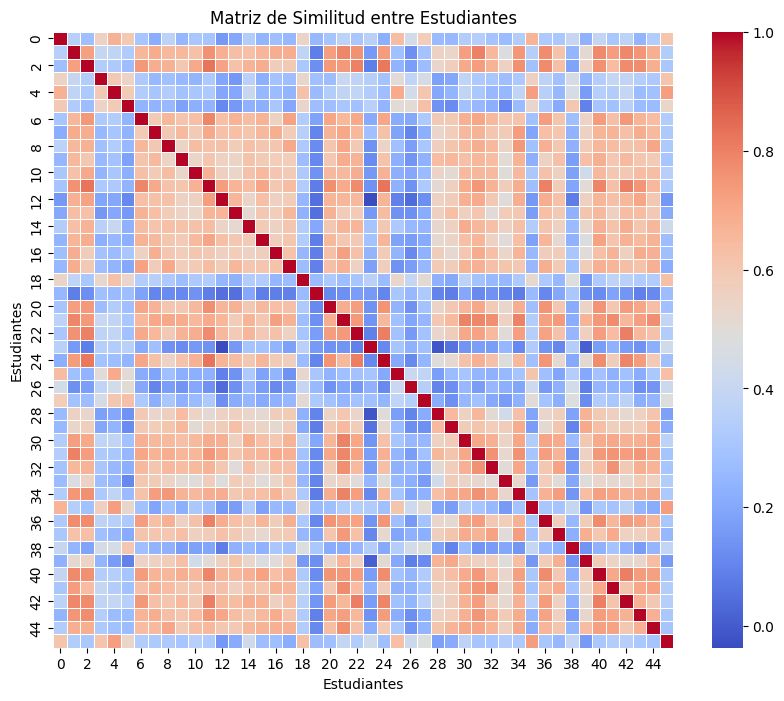

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
sns.heatmap(similarity_matrix, annot=False, cmap="coolwarm", linewidths=0.5)
plt.title("Matriz de Similitud entre Estudiantes")
plt.xlabel("Estudiantes")
plt.ylabel("Estudiantes")
plt.show()


En cuanto a los estudiantes, vemos un mayor numero de semejanzas quiza porque todos hablan de los mismos topícos, sin embargo, hay estudiantes como el 19, 23 y el 38 que escriben de manera muy diferente al resto del grupo.

Para intuir la posibilidad de copia nos inclinamos por los que tengan una similitud igual o superior a 0.8, bajo este criterio los estudiantes que probablemente se copiaron se muestran en la siguiente celda.

In [ ]:
import numpy as np

# Obtener los estudiantes
estudiantes = df.index.tolist()

# Umbral de similitud
umbral = 0.8

# Lista para guardar los pares similares
pares_similares = []

# Recorrer la matriz superior
n = len(estudiantes)
for i in range(n):
    for j in range(i + 1, n):  # Evitar duplicados comparando solo la parte superior de la matriz
        if similarity_matrix[i, j] >= umbral:
            pares_similares.append((estudiantes[i], estudiantes[j], similarity_matrix[i, j]))

# Imprimir los pares encontrados
if pares_similares:
    print("📌 Pares de estudiantes con similitud ≥ 0.8:")
    for est1, est2, sim in pares_similares:
        print(f"{est1} ↔ {est2} → Similitud: {sim:.2f}")
else:
    print("❌ No se encontraron pares con similitud ≥ 0.8")


📌 Pares de estudiantes con similitud ≥ 0.8:
2 ↔ 11 → Similitud: 0.83
2 ↔ 22 → Similitud: 0.80
2 ↔ 24 → Similitud: 0.82
11 ↔ 24 → Similitud: 0.83
11 ↔ 42 → Similitud: 0.80
22 ↔ 24 → Similitud: 0.80
22 ↔ 42 → Similitud: 0.80
40 ↔ 42 → Similitud: 0.80


# Exercise 2.3

Create a classifier to predict the gender of each student



In [ ]:
!pip install optuna

Optimizamos con optuna, añadimos una estandarizacion para mejorar variabilidad, ajustamos en caso de desbalance de genero y usamos un sentence transfomer mas potente para mejorar la prediccion.

In [ ]:

df = data

# Preprocesamiento del texto
df["texto_completo"] = df.iloc[:, 1:].apply(lambda x: " ".join(x.dropna()), axis=1)
df["genero"] = df["Genero"].map({"M": 0, "F": 1})  # 0 = M, 1 = F

# Obtener embeddings con SentenceTransformer
modelo = SentenceTransformer("paraphrase-MiniLM-L6-v2")
X = modelo.encode(df["texto_completo"].tolist())  # Convertir textos a embeddings
y = df["genero"].values  # Etiquetas

# Aplicar reducción de dimensionalidad con PCA
pca = PCA(n_components=45)
X_pca = pca.fit_transform(X)

# Dividir datos
X_train, X_test, y_train, y_test = train_test_split(X_pca, y, test_size=0.2, random_state=42, stratify=y)

# Función de Optimización con Optuna
def objective(trial):
    n_estimators = trial.suggest_int("n_estimators", 50, 500, step=50)
    max_depth = trial.suggest_int("max_depth", 5, 50, step=5)
    min_samples_split = trial.suggest_int("min_samples_split", 2, 20)
    min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 10)

    clf = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        random_state=42,
        n_jobs=-1,
        class_weight="balanced"  # Ajuste para datos desbalanceados
    )

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = cross_val_score(clf, X_train, y_train, cv=cv, scoring="accuracy")
    return np.mean(scores)

# Ejecutar la optimización con Optuna
study = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler())
study.optimize(objective, n_trials=20)

# Entrenar el modelo con los mejores hiperparámetros
best_params = study.best_params
best_clf = RandomForestClassifier(**best_params, random_state=42, n_jobs=-1, class_weight="balanced")
best_clf.fit(X_train, y_train)

# Evaluación final
y_pred = best_clf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Mejor Precisión con Random Forest Optimizado: {accuracy:.4f}")
print(f"Mejores Hiperparámetros: {best_params}")

[I 2025-03-31 01:06:45,295] A new study created in memory with name: no-name-9350ff7c-d818-4d56-9659-87d871aee2b1
[I 2025-03-31 01:06:55,765] Trial 0 finished with value: 0.7785714285714287 and parameters: {'n_estimators': 500, 'max_depth': 45, 'min_samples_split': 8, 'min_samples_leaf': 3}. Best is trial 0 with value: 0.7785714285714287.
[I 2025-03-31 01:07:00,751] Trial 1 finished with value: 0.7785714285714287 and parameters: {'n_estimators': 300, 'max_depth': 35, 'min_samples_split': 12, 'min_samples_leaf': 4}. Best is trial 0 with value: 0.7785714285714287.
[I 2025-03-31 01:07:10,000] Trial 2 finished with value: 0.7785714285714287 and parameters: {'n_estimators': 450, 'max_depth': 15, 'min_samples_split': 3, 'min_samples_leaf': 6}. Best is trial 0 with value: 0.7785714285714287.
[I 2025-03-31 01:07:17,330] Trial 3 finished with value: 0.7785714285714287 and parameters: {'n_estimators': 400, 'max_depth': 50, 'min_samples_split': 15, 'min_samples_leaf': 7}. Best is trial 0 with val

Mejor Precisión con Random Forest Optimizado: 0.8000
Mejores Hiperparámetros: {'n_estimators': 500, 'max_depth': 45, 'min_samples_split': 8, 'min_samples_leaf': 3}


Observamos una accuracy aceptable, sin embargo, los patrones de escritura no diferencian a la perfecccion el genero de los estudiantes

# Exercise 2.4
Classify group members into different subgroups (minimum 3) according to a characteristic of your choice.

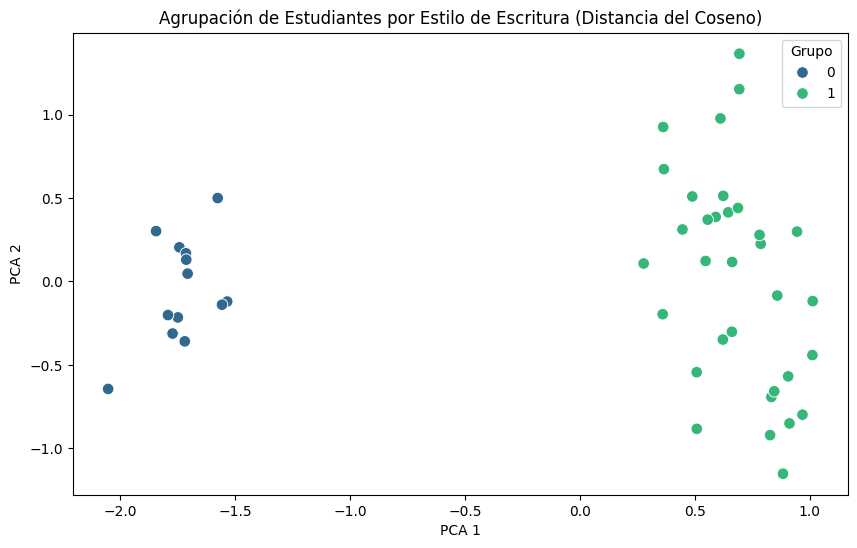

In [ ]:

# Cargar modelo de embeddings
model = SentenceTransformer("paraphrase-MiniLM-L3-v2")

# Convertir textos a embeddings
X = model.encode(df["texto_completo"].tolist())  # Convertir a lista si es necesario

# Calcular la matriz de distancias del coseno
dist_matrix = cosine_distances(X)

# Aplicar clustering jerárquico con distancia del coseno
num_clusters = 2
clustering = AgglomerativeClustering(n_clusters=num_clusters, metric="precomputed", linkage="average")
df["grupo"] = clustering.fit_predict(dist_matrix)

# Reducir dimensiones con PCA para visualizar
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# Visualizar los clusters
plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=df["grupo"], palette="viridis", s=70)
plt.title("Agrupación de Estudiantes por Estilo de Escritura (Distancia del Coseno)")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.legend(title="Grupo")
plt.show()


Vemos un grupo con similitud( en terminos de distancia del coseno), el cual representa la mayoria de los estudiantes lo cual tiene sentido si se tiene en cuenta que todos han escrito sobre los mismos topicos, sin embargo hay un grupo relativamente pequeño que se aleja de estos estilos de escritura, relacionando esto con el modelo esta diferencia no estaria claramente definida por genero.